# **Инструмент для обучения модели word2vec с заданными параметрами, предсказание лексических замен и параметров**

In [1]:
!pip install numpy==1.26.4 scipy==1.11.1 #

In [2]:
!pip install gensim==4.3.1 #Библиотека для обработки естественного языка (NLP).
#Построение word2vec, doc2vec, fastText моделей (векторные представления слов/документов).

  Using cached gensim-4.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.4 kB)
Using cached gensim-4.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)


In [3]:
import gensim
print(gensim.__version__)

4.3.1


In [5]:
from gensim.models import Word2Vec #модель, которая представляет слова в виде векторов (эмбеддингов), захватывающих их семантические и синтаксические связи.
from gensim.models.word2vec import LineSentence #построчная загрузка текстов из файла.

In [6]:
import numpy as np #библиотека для численных вычислений
import matplotlib.pyplot as plt #библиотека для построения графиков.
import seaborn as sns #надстройка над matplotlib, упрощающая визуализацию статистических данных.
import pandas as pd #библиотека для анализа табличных данных.

In [7]:
from sklearn.decomposition import PCA #Сохраняет как можно больше дисперсии данных
from sklearn.manifold import TSNE #Лучше сохраняет локальную структуру данных (кластеры похожих слов)
#используются для снижения размерности векторных представлений слов, чтобы их можно было визуализировать на 2D-графике (через scatter plot).

In [3]:
!pip install pymorphy3

import pymorphy3
import re

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    # Простая токенизация: берём только слова (кириллица + латиница + цифры)
    tokens = re.findall(r'\b\w+\b', text.lower())
    lemmas = []
    for token in tokens:
        lemma = morph.parse(token)[0].normal_form
        lemmas.append(lemma)
    return ' '.join(lemmas)

# Загружаем текст
with open('/content/MM.txt', encoding='utf-8') as f:
    text = f.read()

lemmatized = lemmatize_text(text)

# Сохраняем в файл
with open('ММ_lemm.txt', 'w', encoding='utf-8') as f:
    f.write(lemmatized)

In [14]:
from ufal.udpipe import Model, Pipeline
import wget

# Скачиваем модель UDPipe (если не скачана)
model_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'
model_path = wget.download(model_url)

# Загружаем модель и создаём pipeline
model = Model.load(model_path)
pipeline = Pipeline(model, 'tokenize', Pipeline.DEFAULT, Pipeline.DEFAULT, 'conllu')

# Загружаем стоп-слова из файла
with open('/content/russian (1).txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip().lower() for line in f if line.strip())

# Определяем функцию с удалением пунктуации
def lemmatize_and_tag_no_punct(text):
    processed = pipeline.process(text)
    lines = processed.strip().split('\n')

    sentences = []
    current_sentence = []
    for line in lines:
        if line == '':
            if current_sentence:
                sentences.append(' '.join(current_sentence))
                current_sentence = []
        elif line.startswith('#'):
            continue
        else:
            cols = line.split('\t')
            if len(cols) >= 4:
                lemma = cols[2]
                upos = cols[3]
                if upos != 'PUNCT':  # исключаем пунктуацию
                    token = f"{lemma}_{upos}"
                    current_sentence.append(token)
    if current_sentence:
        sentences.append(' '.join(current_sentence))
    return sentences

# Загружаем текст
with open('/content/MM.txt', encoding='utf-8') as f:
    text = f.read()

# Вызываем функцию
sentences = lemmatize_and_tag_no_punct(text)

# Записываем результат в файл
with open('ММ_lemm_tag_no_punct.txt', 'w', encoding='utf-8') as f:
    for sent in sentences:
        f.write(sent + '\n')

In [15]:
# Обучаем модель Word2Vec на нашем тексте

from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

filename = '/content/ММ_lemm_tag_no_punct.txt'

model = Word2Vec(
    LineSentence(filename), # читаем файл построчно (каждая строка — предложение)
    vector_size=150, # размерность вектора слова
    window=3,  # контекстное окно
    min_count=5, # игнорировать редкие слова
    workers=2 # использовать 2 потока
)

model.save('ММ_lemm_tag.model')

In [16]:
# Загружаем модель
model = Word2Vec.load('/content/ММ_lemm_tag.model')

In [17]:
# Функция, чтобы показать похожие слова
def print_similar_words(word, topn=10):
    print(f"Похожие слова для '{word}':")
    similar = model.wv.most_similar(positive=[word], topn=topn)
    for w, score in similar:
        print(f"  {w} -> {score:.4f}")
    print()

In [18]:
# Проверяем похожие слова для нескольких слов
words_to_test = ['Пилат_PROPN', 'Воланд_PROPN']
for w in words_to_test:
    print_similar_words(w)

Похожие слова для 'Пилат_PROPN':
  на_ADP -> 0.9995
  в_ADP -> 0.9995
  прокуратор_NOUN -> 0.9994
  видеть_VERB -> 0.9994
  и_CCONJ -> 0.9994
  под_ADP -> 0.9994
  он_PRON -> 0.9994
  что_SCONJ -> 0.9994
  за_ADP -> 0.9994
  с_ADP -> 0.9994

Похожие слова для 'Воланд_PROPN':
  он_PRON -> 0.9987
  тут_ADV -> 0.9987
  в_ADP -> 0.9987
  на_ADP -> 0.9987
  а_CCONJ -> 0.9986
  что_SCONJ -> 0.9986
  и_CCONJ -> 0.9986
  то_PRON -> 0.9986
  который_PRON -> 0.9986
  не_PART -> 0.9986



In [21]:
# Считаем сходство между двумя словами
similarity_score = model.wv.similarity('голова_NOUN', 'Пилат_PROPN')
print(f"Сходство между 'голова' и 'Пилат': {similarity_score:.4f}\n")

Сходство между 'голова' и 'Пилат': 0.9994



# Можно посчитать, насколько близки по смыслу два слова. Результат — число от -1 до 1 (больше значит более похожи).

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
# Функция для визуализации слов с помощью t-SNE
def tsnescatterplot(model, word, additional_words=[]):    ## строит вектора для заданного слова + его ближайших + дополнительных
    sns.set_style("darkgrid")    ## устанавливаем стиль графика

    arrays = np.empty((0, model.vector_size), dtype='f')  # массив векторов слов
    word_labels = [word]     # подписи слов на графике
    color_list = ['red']     # цвета для слов (красный — исходное слово)

    # Добавляем вектор исходного слова
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    # # Получаем 10 ближайших слов и добавляем их в массив векторов
    close_words = model.wv.most_similar([word], topn=10)
    for wrd, _ in close_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)     # # добавляем подпись
        color_list.append('blue')  # похожие слова — синие

    # Добавляем дополнительные слова (если есть)
    for wrd in additional_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)      # # добавляем подпись
        color_list.append('green')  # зелёныe - для вручную указанных слов

    # Сначала уменьшаем размерность до 4 с помощью PCA — ускоряет работу t-SNE
    pca_result = PCA(n_components=4).fit_transform(arrays)

    # Потом уменьшаем до 2D с помощью t-SNE для визуализации
    tsne = TSNE(n_components=2, perplexity=min(5, len(arrays)), n_iter=1000, random_state=0)
    tsne_result = tsne.fit_transform(pca_result)

    # Создаём таблицу для удобного рисования
    df = pd.DataFrame({
        'x': tsne_result[:, 0],      # координата X
        'y': tsne_result[:, 1],      # координата Y
        'word': word_labels,         # подпись (слово)
        'color': color_list          # цвет точки
    })

    # Рисуем график
    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)

    # Подписываем слова рядом с точками
    for i in range(len(df)):
        plt.text(df.x[i]+0.1, df.y[i]+0.1, df.word[i], fontsize=12)

    plt.title(f't-SNE визуализация для слова: {word}')
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipython-input-30-2524300735.py:48: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)


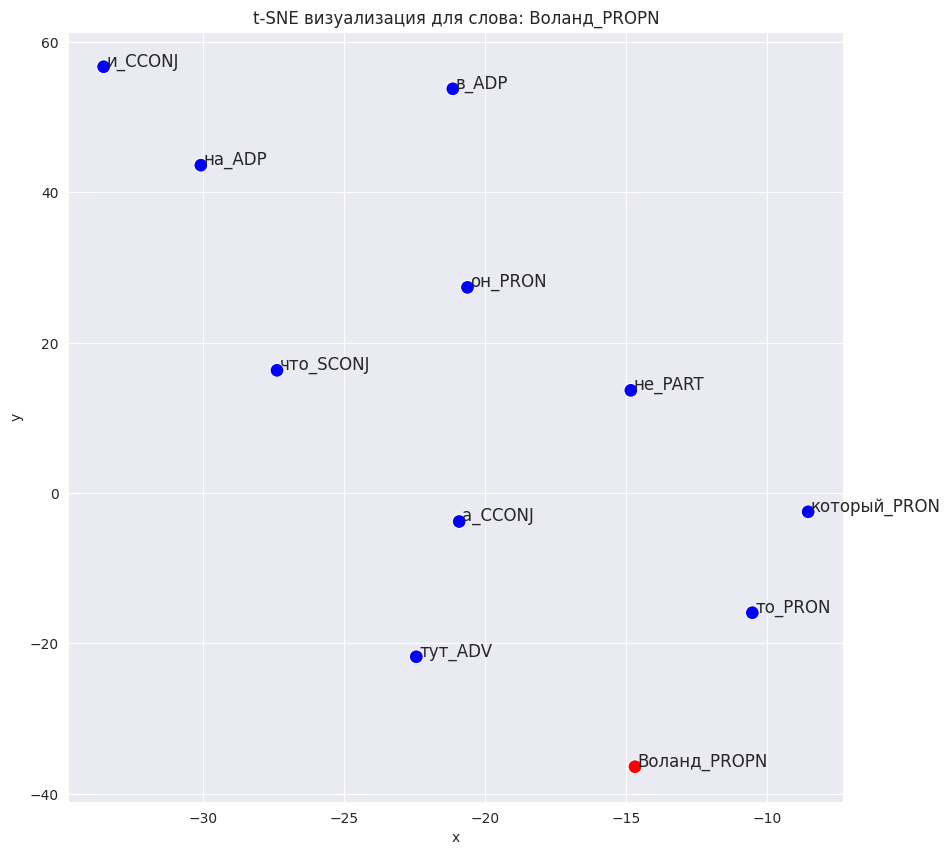

In [31]:
# Визуализируем слово 'Волад'
tsnescatterplot(model, 'Воланд_PROPN')


*   В этом задании мне нужно было обучить модель Word2Vec на корпусе произведения "Мастер и Маргарита" М.А. Булгакова (в лемматизированном виде), чтобы найти семантические связи между словами.

*   Сначала я использовала библиотеку Gensim, чтобы обучить модель Word2Vec на файле MM.txt. Я установила параметры — размер вектора, размер окна, минимальное количество вхождений. После обучения я сохранила модель.
*   Затем я загрузила эту модель и с помощью неё:

*   Нашла 10 самых похожих слов к выбранным словам (например, 'Пилат', 'Воланд').

*   Вычислила степень семантического сходства между двумя словами ('голова', 'Пилат').

*   Построила визуализацию с помощью t-SNE, чтобы показать, как слова расположены в векторном пространстве и какие из них ближе друг к другу по значению.

*   Для визуализации я сначала уменьшила размерность с помощью PCA до 4, а потом применила t-SNE для уменьшения до 2 измерений, и отобразила это с помощью графика в matplotlib и seaborn.

*  Таким образом, я продемонстрировала, что модель умеет находить семантически близкие слова и отображать их визуально.















